## Setup and Data Loading

In [10]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # Added Random Forest Classifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to address the LookupError

# Load Dataset (Example: Using a sample CSV or creating a dummy for structure)
# Replace this with: df = pd.read_csv('your_dataset.csv')
df = pd.read_csv('IMDB Dataset.csv')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## NLP Preprocessing

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercasing
    text = text.lower()
    # 2. Removing URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)
    # 3. Removing punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # 4. Tokenization & Removing stopwords
    tokens = nltk.word_tokenize(text)
    # 5. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(cleaned_tokens)

# Apply the function
df['cleaned_review'] = df['review'].apply(clean_text)
print(df[['review', 'cleaned_review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching 1 oz episode y...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


## Feature Engineering (BoW & TF-IDF)

In [8]:
X = df['cleaned_review']
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization (Recommended for better accuracy)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Bag of Words (BoW)
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

## Model Building & Comparison


--- Logistic Regression Performance ---
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


--- Naive Bayes Performance ---
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


--- Decision Tree Performance ---
              precision    recall  f1-score   support

    negative       0.71      0.72      0.72      4961
    positive       0.72      0.71      0.72      5039

    accuracy                           0.72     10000
   macro avg       

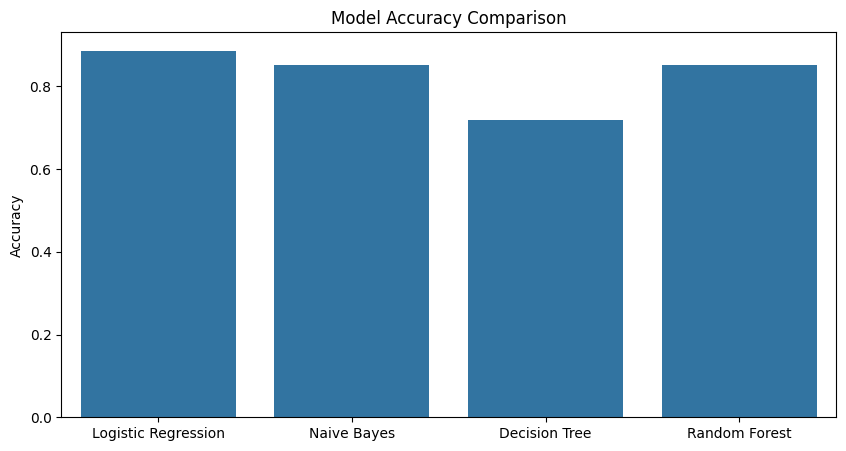

In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    # Training using TF-IDF features
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    # Evaluation
    acc = accuracy_score(y_test, predictions)
    results[name] = acc

    print(f"\n--- {name} Performance ---")
    print(classification_report(y_test, predictions))

# Summary Visualization
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()